# Normalizing flows on 2D toy densities

Trains `probjax.nn.maf` (a masked affine autoregressive flow) as a density estimator on three classic 2D toy distributions, then plots the training data next to flow samples and the learned log-density.

Every flow family in `probjax.nn.generative.flows` follows the same recipe: build it, call `.fit(rng, data)` to train in place, then use `.as_dist(event_shape)` for a scipy-like `.sample()` / `.logpdf()` view.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx

from probjax.nn import maf

from data import CheckerboardGenerator, CrescentGenerator, SpiralGenerator

## Datasets

`data.py` (next to this notebook) has three generators that each return `(num_points, 2)` samples: a checkerboard, a spiral, and a crescent (moon-shaped) distribution.

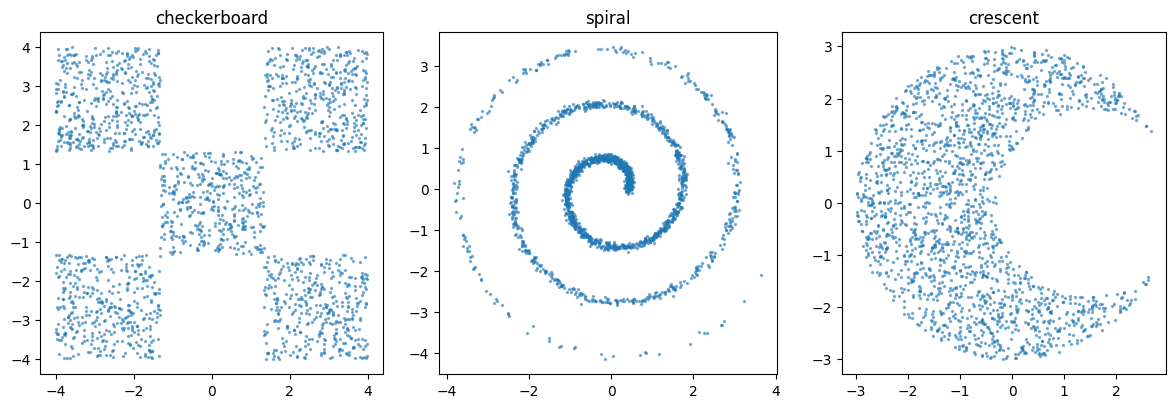

In [2]:
datasets = {
    "checkerboard": CheckerboardGenerator(grid_size=3, scale=4.0),
    "spiral": SpiralGenerator(n_turns=3, radius_scale=4.0, noise_std=0.05),
    "crescent": CrescentGenerator(R=3.0, r=1.8, d=1.5),
}

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, gen) in zip(axes, datasets.items()):
    x = gen.generate(2000, key=jax.random.key(0))
    ax.scatter(x[:, 0], x[:, 1], s=2, alpha=0.5)
    ax.set_title(name)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Train a flow per dataset

`maf(input_dim, num_transforms, rngs=...)` stacks affine autoregressive layers (with `Flip` mixing in between) over a standard-normal base distribution. `.fit` runs a plain Adam loop over the negative log-likelihood and updates the flow's parameters in place.

checkerboard: nll 8.06 -> 3.69
spiral: nll 3.74 -> 2.62
crescent: nll 4.35 -> 3.09


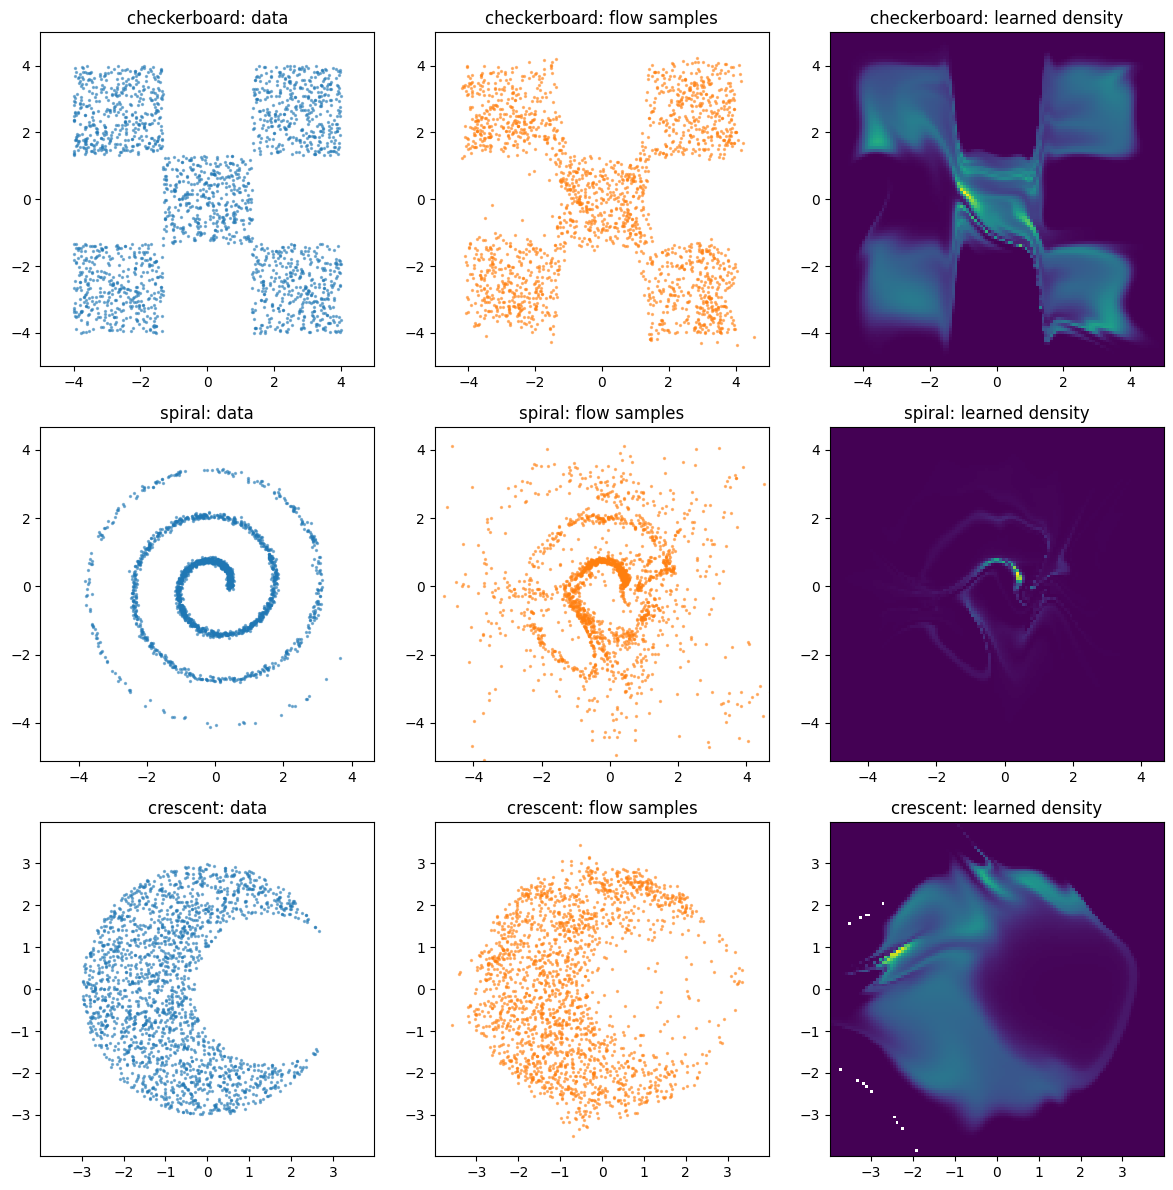

In [3]:
def train_flow(data, *, num_transforms=6, num_steps=10_000, seed=0):
    flow = maf(2, num_transforms, rngs=nnx.Rngs(seed))
    losses = flow.fit(jax.random.key(seed + 1), data, num_steps=num_steps, batch_size=256)
    return flow, losses


def plot_flow(ax_data, ax_samples, ax_density, name, data, flow):
    dist = flow.as_dist((2,))
    samples = dist.sample(jax.random.key(0), (2000,))

    lo, hi = data.min() - 1.0, data.max() + 1.0
    grid_1d = jnp.linspace(lo, hi, 120)
    xx, yy = jnp.meshgrid(grid_1d, grid_1d)
    grid = jnp.stack([xx.ravel(), yy.ravel()], axis=-1)
    density = jnp.exp(dist.logpdf(grid)).reshape(xx.shape)

    ax_data.scatter(data[:, 0], data[:, 1], s=2, alpha=0.5)
    ax_data.set_title(f"{name}: data")
    ax_samples.scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.5, color="C1")
    ax_samples.set_title(f"{name}: flow samples")
    ax_density.pcolormesh(xx, yy, density, shading="auto")
    ax_density.set_title(f"{name}: learned density")
    for ax in (ax_data, ax_samples, ax_density):
        ax.set_aspect("equal")
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)


trained = {}
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for row, (name, gen) in zip(axes, datasets.items()):
    data = gen.generate(2000, key=jax.random.key(0))
    flow, losses = train_flow(data, seed=hash(name) % 1000)
    trained[name] = (flow, data)
    print(f"{name}: nll {float(losses[0]):.2f} -> {float(losses[-1]):.2f}")
    plot_flow(*row, name, data, flow)
plt.tight_layout()
plt.show()

`maf` fits the checkerboard and crescent well. The spiral is harder: an affine autoregressive flow has to unroll a tightly curved, topologically 1D manifold, and tends to under-cover it (visible in the middle column above) unless given many more transforms — which in turn risks the log-scale blowup affine coupling layers are known for. This is a real limitation of the architecture, not a bug.

## Other architectures

`probjax.nn.generative.flows` also has autoregressive flows with more expressive elementwise transforms: `naf` (deep sigmoidal), `unaf` (monotone-network integrand), `sospf` (sum-of-squares polynomial), `bpf` (Bernstein polynomial) and `gf` (Gaussianization). It also has coupling-based flows (`nice`, `realnvp`) and a spline flow (`nsf`). They all follow the exact same `ctor(input_dim, num_transforms, rngs=...)` + `.fit` recipe as `maf` above.

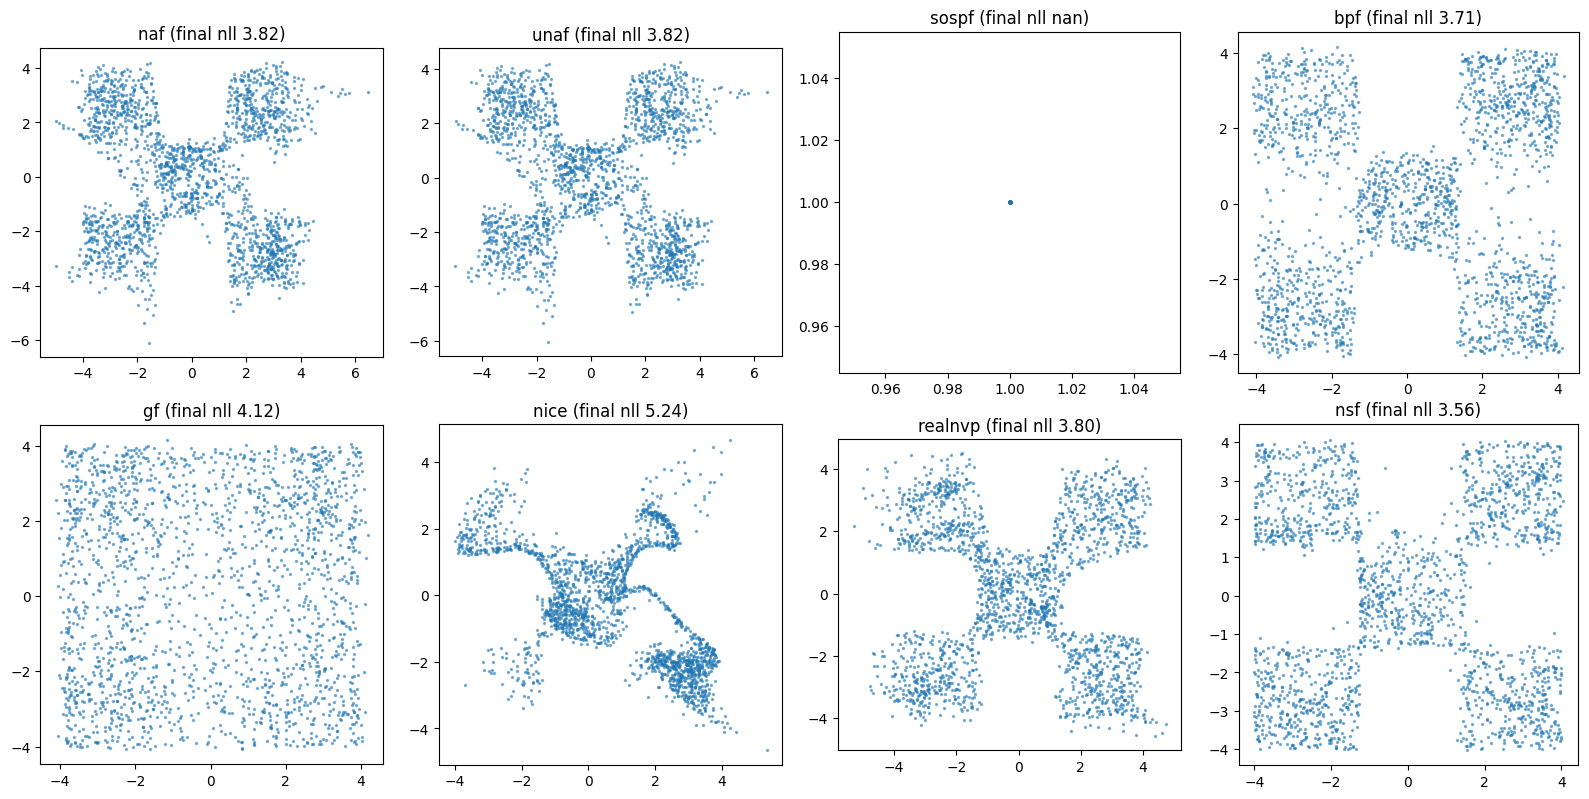

In [4]:
from probjax.nn import bpf, gf, naf, nice, nsf, realnvp, sospf, unaf

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
data = datasets["checkerboard"].generate(2000, key=jax.random.key(0))

for ax, (arch_name, ctor) in zip(
    axes.ravel(),
    {
        "naf": lambda: naf(2, 4, rngs=nnx.Rngs(1)),
        "unaf": lambda: unaf(2, 4, rngs=nnx.Rngs(1)),
        "sospf": lambda: sospf(2, 4, rngs=nnx.Rngs(1)),
        "bpf": lambda: bpf(2, 4, rngs=nnx.Rngs(1)),
        "gf": lambda: gf(2, 4, rngs=nnx.Rngs(1)),
        "nice": lambda: nice(2, 4, rngs=nnx.Rngs(1)),
        "realnvp": lambda: realnvp(2, 4, rngs=nnx.Rngs(1)),
        "nsf": lambda: nsf(2, 4, rngs=nnx.Rngs(1)),
    }.items(),
):
    flow = ctor()
    losses = flow.fit(jax.random.key(2), data, num_steps=5000, batch_size=256)
    samples = flow.as_dist((2,)).sample(jax.random.key(0), (2000,))
    ax.scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.5)
    ax.set_title(f"{arch_name} (final nll {float(losses[-200:].mean()):.2f})")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()